# 53 Boost 2 — XGBoost, GradientBoosting y AdaBoost

Tres algoritmos de boosting sobre `sale` y `rent` prediciendo `log_precio`.

- Features fijas definidas manualmente (ya numéricas/binarias)
- Municipios con < 10 observaciones se unifican en `municipio_otro`
- Split 80/20 train-test, CV de 5 folds
- Primero modelo base (hiperparámetros por defecto) y luego GridSearchCV

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
)
from sklearn.model_selection import train_test_split, GridSearchCV

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)

# ── Configuración ─────────────────────────────────────────────────────────────
RANDOM_STATE      = 42
TEST_SIZE         = 0.20
TARGET_COL        = "log_precio"
CV_FOLDS          = 5
MIN_OBS_MUNICIPIO = 10   # municipios con menos observaciones → municipio_otro

# ── Rutas ─────────────────────────────────────────────────────────────────────
def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "gold").exists():
            return p
    raise FileNotFoundError("No se encontró la raíz del proyecto (data/gold)")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATASETS = {
    "sale": PROJECT_ROOT / "data" / "gold" / "final_sale.csv",
    "rent": PROJECT_ROOT / "data" / "gold" / "final_rent.csv",
}

print("Datasets:")
for name, path in DATASETS.items():
    print(f"  {name}: {path}")

Datasets:
  sale: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_sale.csv
  rent: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_rent.csv


In [2]:
# ── Features ──────────────────────────────────────────────────────────────────
BASE_FEATURES = [
    "superficie_construida_m2",
    "numero_dormitorios",
    "numero_banos",
    "latitud",
    "longitud",
    "tiene_garaje",
    "obra_nueva",
    "distancia_min_playa_km",
    "distancia_min_supermercado_km",
    "distancia_min_colegio_km",
    "distancia_centro_municipio_km",
    "score_cercania_servicios",
    "tipologia_unificada_piso",
    "tipologia_unificada_unifamiliar",
]

MUNICIPIO_FEATURES = [
    "municipio_Ampuero",
    "municipio_Barcena de Cicero",
    "municipio_Camargo",
    "municipio_Cartes",
    "municipio_Castro-Urdiales",
    "municipio_Colindres",
    "municipio_Cudon",
    "municipio_El Astillero",
    "municipio_Entrambasaguas",
    "municipio_Gallarta",
    "municipio_Getxo",
    "municipio_Guarnizo",
    "municipio_Guriezo",
    "municipio_Laredo",
    "municipio_Liendo",
    "municipio_Limpias",
    "municipio_Marina de Cudeyo",
    "municipio_Miengo",
    "municipio_Noja",
    "municipio_Piélagos",
    "municipio_Polanco",
    "municipio_Ramales de la Victoria",
    "municipio_Reocin",
    "municipio_Ribamontan al Mar",
    "municipio_Santa Cruz de Bezana",
    "municipio_Santa Maria de Cayon",
    "municipio_Santander",
    "municipio_Santillana del Mar",
    "municipio_Santoña",
    "municipio_Santurtzi",
    "municipio_Sobremazas",
    "municipio_Solares",
    "municipio_Suances",
    "municipio_Torrelavega",
    "municipio_Villaescusa",
    "municipio_Villapresente",
    "municipio_Viveda",
    "municipio_Voto",
]

# ── Hiperparámetros: grids de búsqueda ────────────────────────────────────────
PARAM_GRID_XGB = {
    "n_estimators":     [200, 400],
    "max_depth":        [3, 4, 5],
    "learning_rate":    [0.05, 0.1],
    "subsample":        [0.7, 0.9],
    "colsample_bytree": [0.7, 0.9],
    "min_child_weight": [3, 5],
    "reg_lambda":       [1, 5],
}

PARAM_GRID_GBR = {
    "n_estimators":    [200, 400],
    "max_depth":       [3, 4, 5],
    "learning_rate":   [0.05, 0.1],
    "subsample":       [0.7, 0.9],
    "min_samples_leaf": [5, 10],
}

PARAM_GRID_ADA = {
    "n_estimators":         [100, 200, 400],
    "learning_rate":        [0.5, 1.0, 1.5],
    "estimator__max_depth": [3, 5, 7],
}

In [3]:
# ── Funciones auxiliares ──────────────────────────────────────────────────────

def get_metrics(y_real, y_pred) -> pd.DataFrame:
    mse  = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_real, y_pred)
    r2   = r2_score(y_real, y_pred)
    mape = mean_absolute_percentage_error(y_real, y_pred)
    return pd.DataFrame({
        "MSE":  [round(mse,  5)],
        "RMSE": [round(rmse, 5)],
        "MAE":  [round(mae,  5)],
        "R2":   [round(r2,   5)],
        "MAPE": [round(mape, 5)],
    })


def collapse_rare_municipios(df: pd.DataFrame, muni_cols: list, min_obs: int) -> tuple:
    """
    Identifica las columnas de municipio con menos de `min_obs` observaciones
    (suma de la columna binaria) y las colapsa en 'municipio_otro'.
    Devuelve el DataFrame modificado y la lista de columnas municipio resultante.
    """
    present = [c for c in muni_cols if c in df.columns]
    absent  = [c for c in muni_cols if c not in df.columns]
    if absent:
        print(f"  Municipios no presentes en el dataset: {absent}")

    counts = df[present].sum()
    rare   = counts[counts < min_obs].index.tolist()
    common = counts[counts >= min_obs].index.tolist()

    print(f"  Municipios con >= {min_obs} obs: {len(common)}")
    print(f"  Municipios con <  {min_obs} obs (→ municipio_otro): {len(rare)}")
    if rare:
        print(f"    {rare}")

    if rare:
        df = df.copy()
        df["municipio_otro"] = df[rare].any(axis=1).astype(int)
        df = df.drop(columns=rare)
        final_muni_cols = common + ["municipio_otro"]
    else:
        final_muni_cols = common

    return df, final_muni_cols


def prepare_X(df: pd.DataFrame, feature_cols: list) -> pd.DataFrame:
    """Selecciona features disponibles, imputa nulos con mediana."""
    cols = [c for c in feature_cols if c in df.columns]
    X = df[cols].copy()
    imputer = SimpleImputer(strategy="median")
    X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)
    return X


def plot_diagnostics(y_test, pred_test, title_prefix: str):
    residuals = y_test - pred_test
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    ax = axes[0]
    ax.scatter(y_test, pred_test, alpha=0.5, s=15)
    lim = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
    ax.plot(lim, lim, "r--", linewidth=1)
    ax.set_title(f"{title_prefix} | Real vs Predicho")
    ax.set_xlabel("Real (log_precio)")
    ax.set_ylabel("Predicho (log_precio)")

    ax = axes[1]
    ax.hist(residuals, bins=30, alpha=0.7, color="steelblue")
    ax.axvline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{title_prefix} | Residuos (test)")
    ax.set_xlabel("Residuo (real − predicho)")
    ax.set_ylabel("Frecuencia")

    ax = axes[2]
    stats.probplot(residuals, dist="norm", plot=ax)
    ax.set_title(f"{title_prefix} | Q-Q plot residuos")

    plt.tight_layout()
    plt.show()


def plot_feature_importance(importances: np.ndarray, feature_names: list, title: str, top_n: int = 15):
    fi = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(top_n)
    )
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(fi["feature"][::-1], fi["importance"][::-1], color="steelblue")
    ax.set_title(title)
    ax.set_xlabel("Importancia")
    plt.tight_layout()
    plt.show()
    return fi


def run_base_model(model, X_train, X_test, y_train, y_test, model_name: str, dataset_name: str):
    """Entrena modelo base y muestra métricas."""
    print(f"\n--- {model_name} | Modelo base ---")
    model.fit(X_train, y_train)
    m_train = get_metrics(y_train, model.predict(X_train))
    m_test  = get_metrics(y_test,  model.predict(X_test))
    summary = pd.concat([
        m_train.assign(split="train"),
        m_test.assign(split="test"),
    ], ignore_index=True)[["split", "MSE", "RMSE", "MAE", "R2", "MAPE"]]
    print(summary.to_string(index=False))
    delta_r2 = float(m_train["R2"].iloc[0]) - float(m_test["R2"].iloc[0])
    ratio    = float(m_test["RMSE"].iloc[0]) / max(float(m_train["RMSE"].iloc[0]), 1e-9)
    print(f"  Sobreajuste → ratio RMSE test/train: {ratio:.4f} | delta R2: {delta_r2:.4f}")
    return model, m_train, m_test


def run_grid_search(estimator, param_grid, X_train, X_test, y_train, y_test, model_name: str, dataset_name: str):
    """Ejecuta GridSearchCV y muestra métricas del mejor modelo."""
    n_comb = int(np.prod([len(v) for v in param_grid.values()]))
    print(f"\n--- {model_name} | GridSearch ({n_comb} combinaciones, CV={CV_FOLDS}) ---")
    gs = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        cv=CV_FOLDS,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )
    gs.fit(X_train, y_train)
    cv_rmse     = float(-gs.best_score_)
    best_model  = gs.best_estimator_
    print(f"  Mejores params: {gs.best_params_}")
    print(f"  CV RMSE (mejor): {cv_rmse:.5f}")

    m_train = get_metrics(y_train, best_model.predict(X_train))
    m_test  = get_metrics(y_test,  best_model.predict(X_test))
    summary = pd.concat([
        m_train.assign(split="train"),
        pd.DataFrame({"split": ["CV"], "MSE": [None], "RMSE": [round(cv_rmse, 5)], "MAE": [None], "R2": [None], "MAPE": [None]}),
        m_test.assign(split="test"),
    ], ignore_index=True)[["split", "MSE", "RMSE", "MAE", "R2", "MAPE"]]
    print(summary.to_string(index=False))
    delta_r2 = float(m_train["R2"].iloc[0]) - float(m_test["R2"].iloc[0])
    ratio    = float(m_test["RMSE"].iloc[0]) / max(float(m_train["RMSE"].iloc[0]), 1e-9)
    print(f"  Sobreajuste → ratio RMSE test/train: {ratio:.4f} | delta R2: {delta_r2:.4f}")
    return best_model, gs, m_train, m_test, cv_rmse


print("Funciones cargadas.")

Funciones cargadas.



DATASET: SALE
Filas cargadas: 588

Agrupando municipios con < 10 observaciones:
  Municipios no presentes en el dataset: ['municipio_Sobremazas', 'municipio_Villaescusa', 'municipio_Viveda']
  Municipios con >= 10 obs: 13
  Municipios con <  10 obs (→ municipio_otro): 22
    ['municipio_Ampuero', 'municipio_Barcena de Cicero', 'municipio_Cartes', 'municipio_Colindres', 'municipio_Cudon', 'municipio_El Astillero', 'municipio_Entrambasaguas', 'municipio_Gallarta', 'municipio_Getxo', 'municipio_Guarnizo', 'municipio_Guriezo', 'municipio_Liendo', 'municipio_Limpias', 'municipio_Marina de Cudeyo', 'municipio_Miengo', 'municipio_Ramales de la Victoria', 'municipio_Reocin', 'municipio_Ribamontan al Mar', 'municipio_Santa Maria de Cayon', 'municipio_Santillana del Mar', 'municipio_Solares', 'municipio_Villapresente']
Features finales: 28 | Filas: 588
Train: 470 | Test: 118

────────────────────────────────────────────────────────────
XGBOOST
───────────────────────────────────────────────────

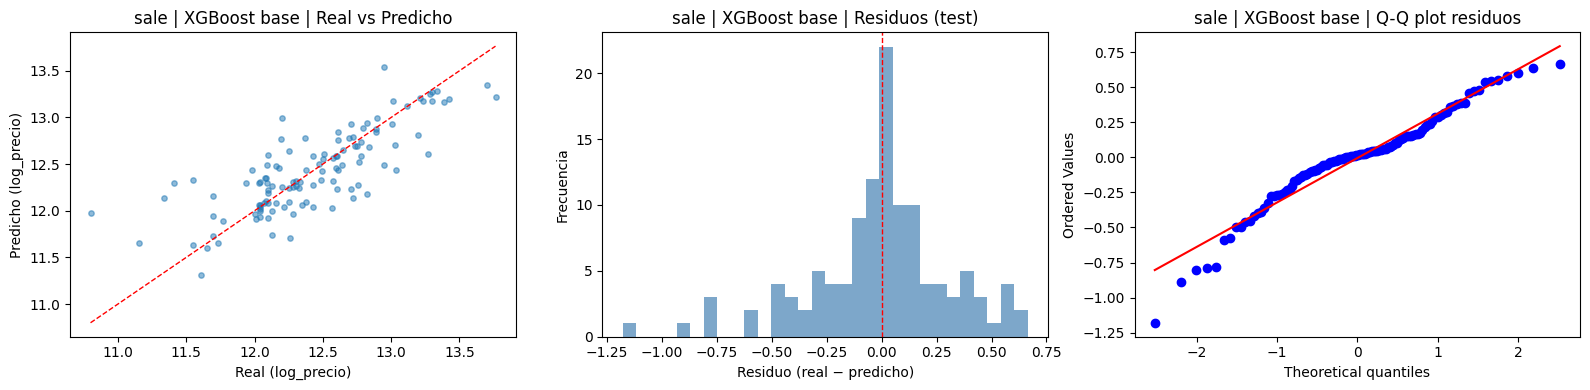

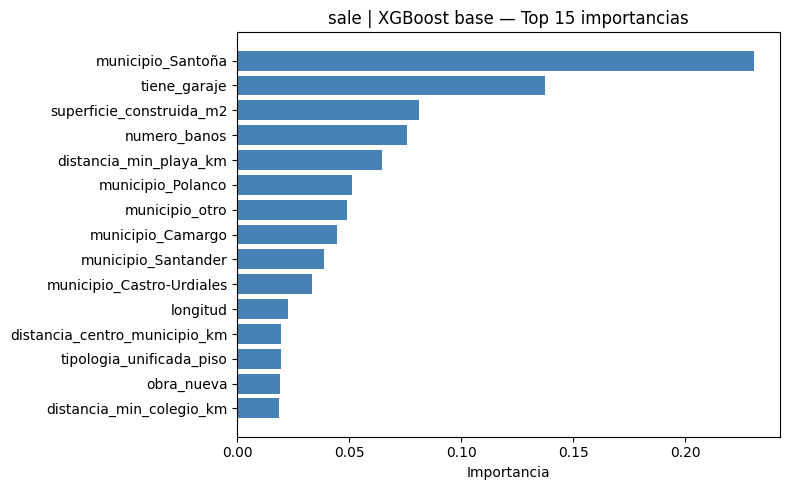


--- XGBoost | GridSearch (192 combinaciones, CV=5) ---
  Mejores params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 200, 'reg_lambda': 5, 'subsample': 0.9}
  CV RMSE (mejor): 0.35709
split     MSE    RMSE     MAE      R2    MAPE
train 0.01558 0.12483 0.09002 0.95230 0.00736
   CV     NaN 0.35709     NaN     NaN     NaN
 test 0.09760 0.31240 0.22194 0.64155 0.01809
  Sobreajuste → ratio RMSE test/train: 2.5026 | delta R2: 0.3108


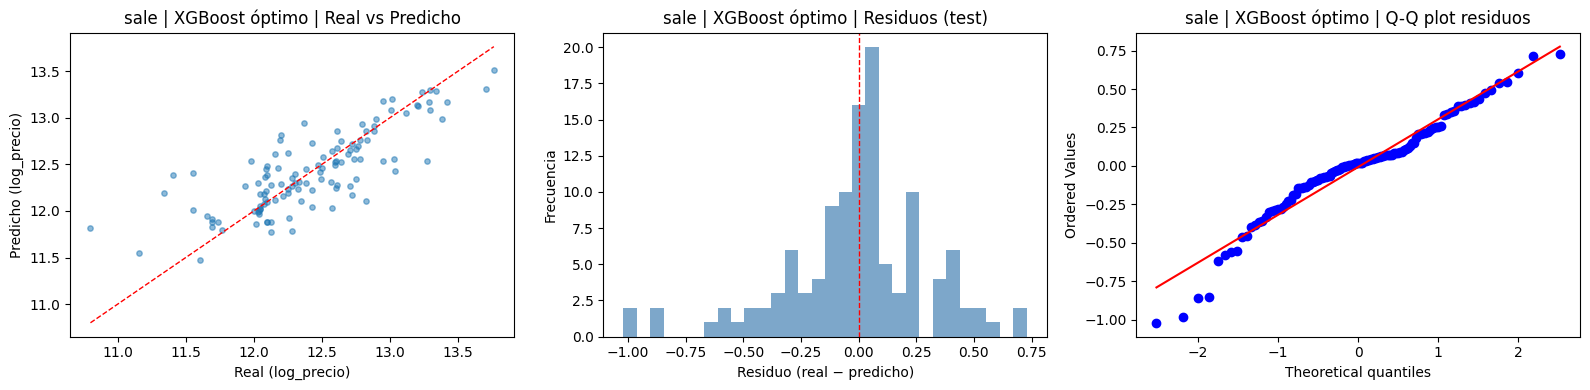

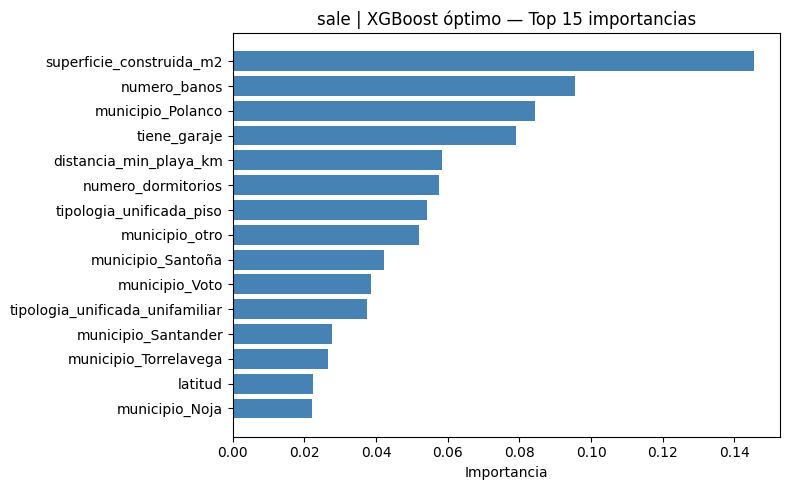


────────────────────────────────────────────────────────────
GRADIENT BOOSTING (sklearn)
────────────────────────────────────────────────────────────

--- GBR | Modelo base ---
split     MSE    RMSE     MAE      R2    MAPE
train 0.03926 0.19815 0.14754 0.87982 0.01203
 test 0.10719 0.32739 0.23552 0.60633 0.01913
  Sobreajuste → ratio RMSE test/train: 1.6522 | delta R2: 0.2735


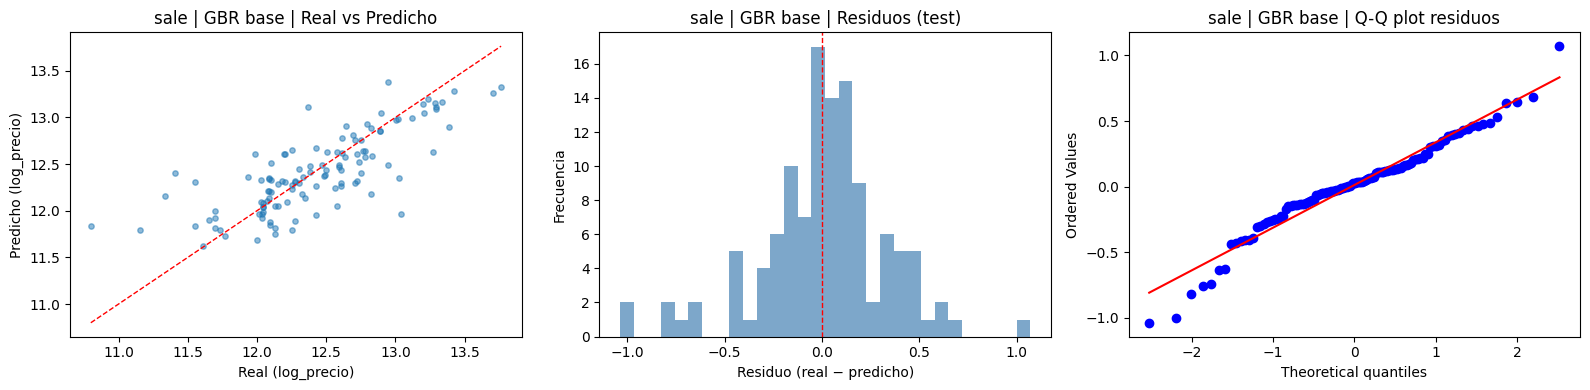

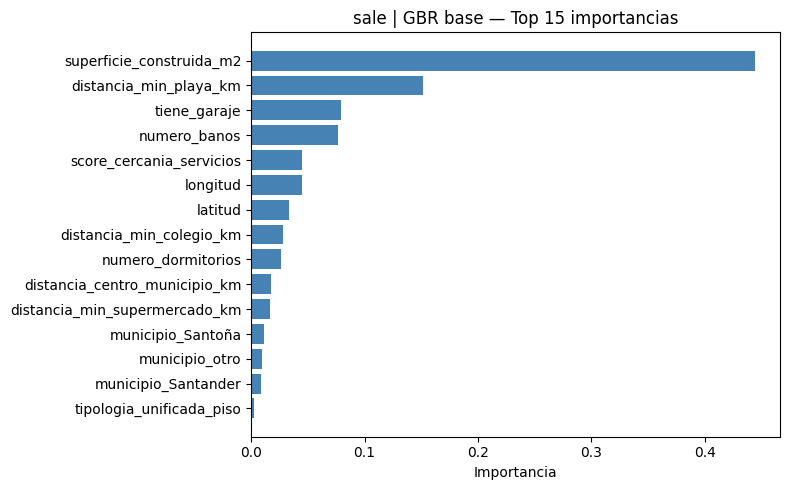


--- GBR | GridSearch (48 combinaciones, CV=5) ---
  Mejores params: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 200, 'subsample': 0.9}
  CV RMSE (mejor): 0.36481
split     MSE    RMSE     MAE      R2    MAPE
train 0.04125 0.20309 0.14770 0.87375 0.01208
   CV     NaN 0.36481     NaN     NaN     NaN
 test 0.09378 0.30623 0.22225 0.65558 0.01805
  Sobreajuste → ratio RMSE test/train: 1.5079 | delta R2: 0.2182


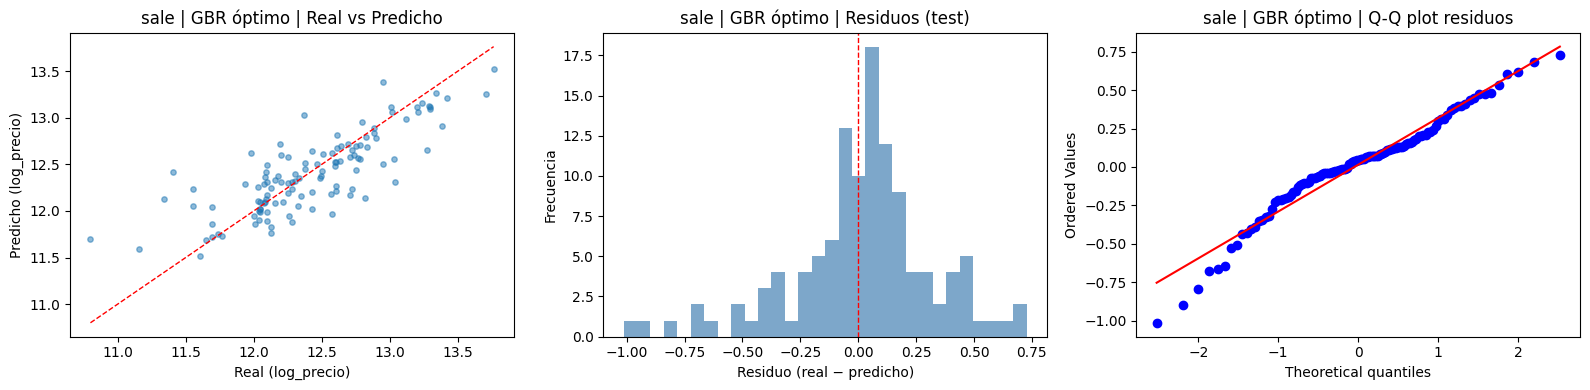

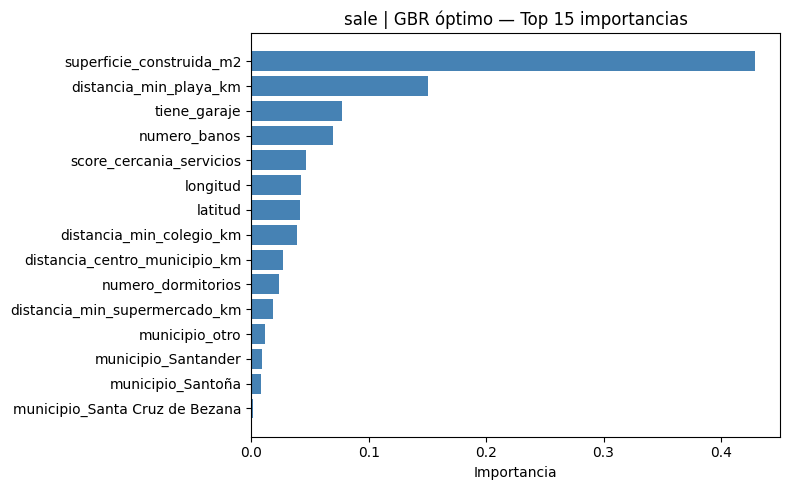


────────────────────────────────────────────────────────────
ADABOOST
────────────────────────────────────────────────────────────

--- AdaBoost | Modelo base ---
split     MSE    RMSE     MAE      R2    MAPE
train 0.09517 0.30849 0.25698 0.70870 0.02079
 test 0.12603 0.35500 0.28482 0.53714 0.02298
  Sobreajuste → ratio RMSE test/train: 1.1508 | delta R2: 0.1716


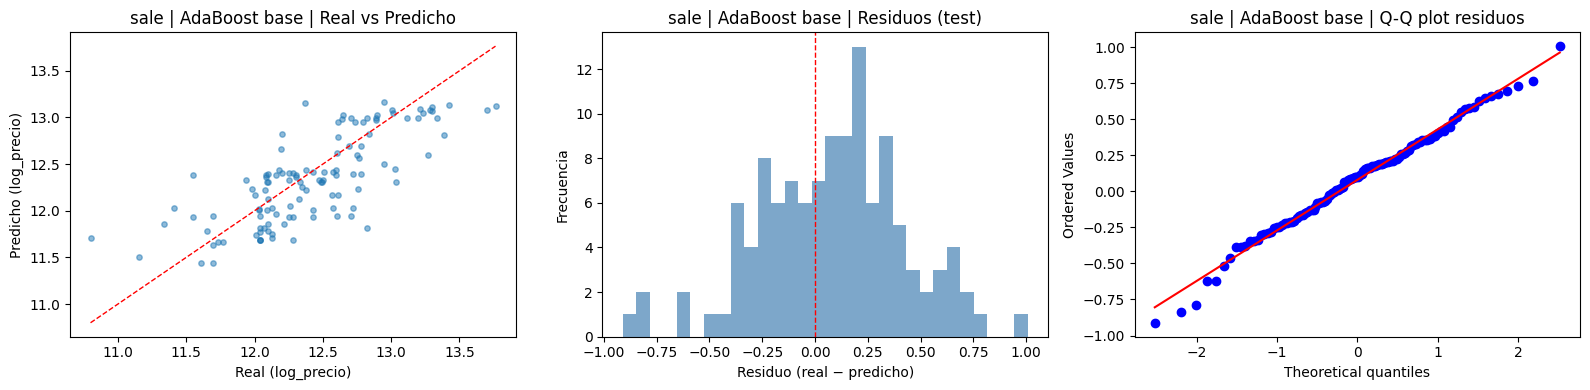

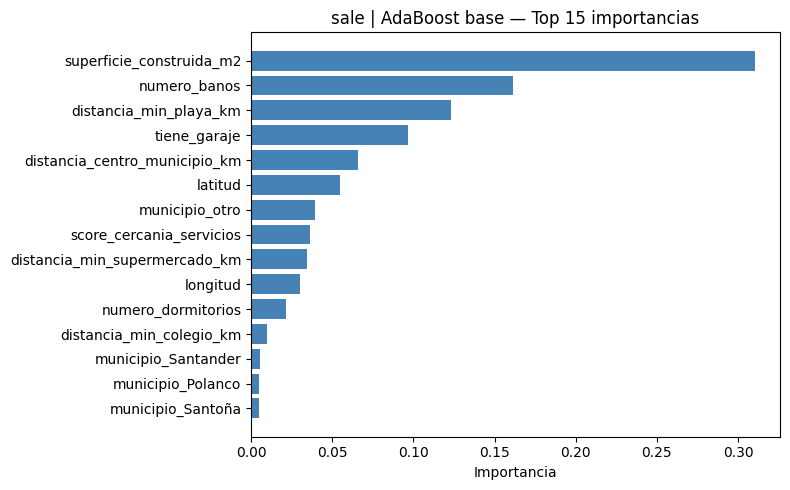


--- AdaBoost | GridSearch (27 combinaciones, CV=5) ---
  Mejores params: {'estimator__max_depth': 7, 'learning_rate': 1.5, 'n_estimators': 400}
  CV RMSE (mejor): 0.35601
split     MSE    RMSE     MAE      R2    MAPE
train 0.00980 0.09897 0.07638 0.97001 0.00617
   CV     NaN 0.35601     NaN     NaN     NaN
 test 0.08929 0.29881 0.21321 0.67207 0.01739
  Sobreajuste → ratio RMSE test/train: 3.0192 | delta R2: 0.2979


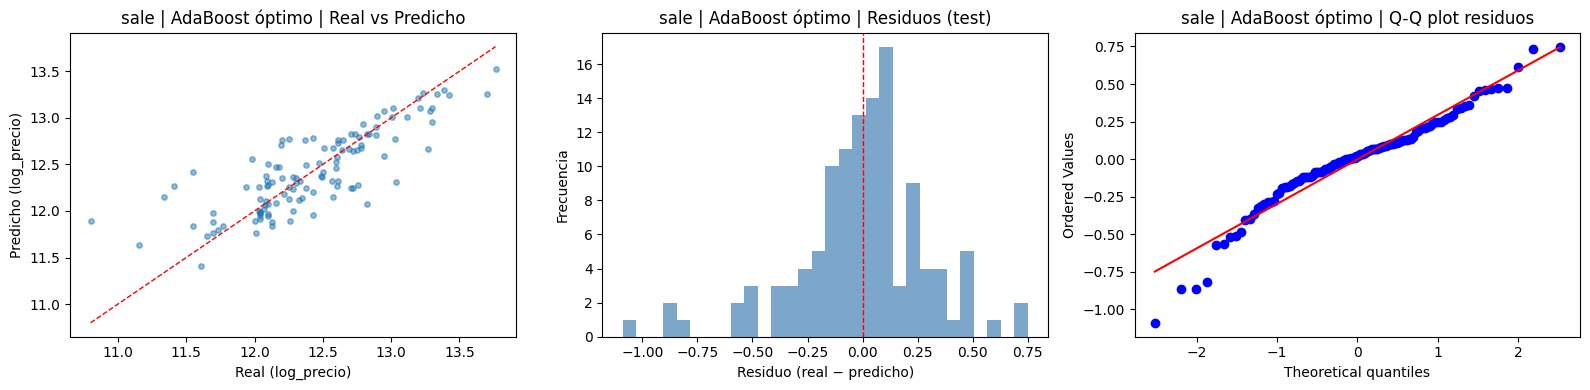

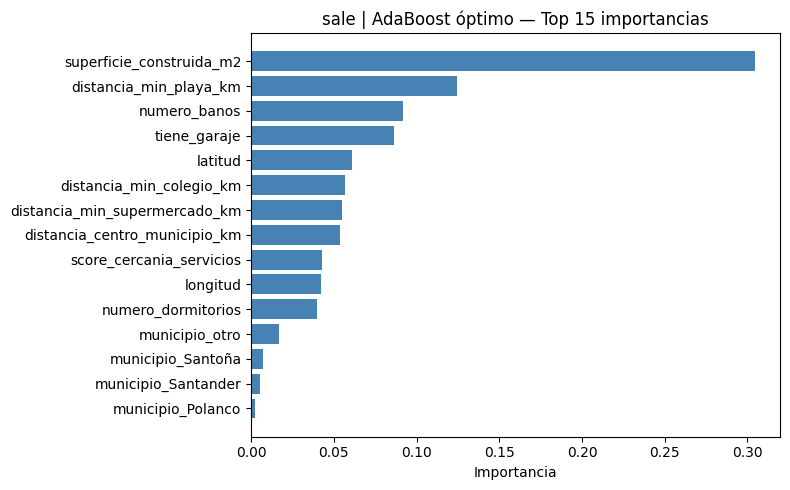


RESUMEN SALE — comparativa modelos
dataset   modelo   fase  train_RMSE  test_RMSE  train_R2  test_R2  cv_RMSE
   sale  XGBoost   base     0.00624    0.31869   0.99988  0.62697      NaN
   sale  XGBoost optimo     0.12483    0.31240   0.95230  0.64155  0.35709
   sale      GBR   base     0.19815    0.32739   0.87982  0.60633      NaN
   sale      GBR optimo     0.20309    0.30623   0.87375  0.65558  0.36481
   sale AdaBoost   base     0.30849    0.35500   0.70870  0.53714      NaN
   sale AdaBoost optimo     0.09897    0.29881   0.97001  0.67207  0.35601

DATASET: RENT
Filas cargadas: 477

Agrupando municipios con < 10 observaciones:
  Municipios con >= 10 obs: 9
  Municipios con <  10 obs (→ municipio_otro): 29
    ['municipio_Ampuero', 'municipio_Barcena de Cicero', 'municipio_Cartes', 'municipio_Colindres', 'municipio_Cudon', 'municipio_Entrambasaguas', 'municipio_Gallarta', 'municipio_Getxo', 'municipio_Guarnizo', 'municipio_Guriezo', 'municipio_Liendo', 'municipio_Limpias', 'munic

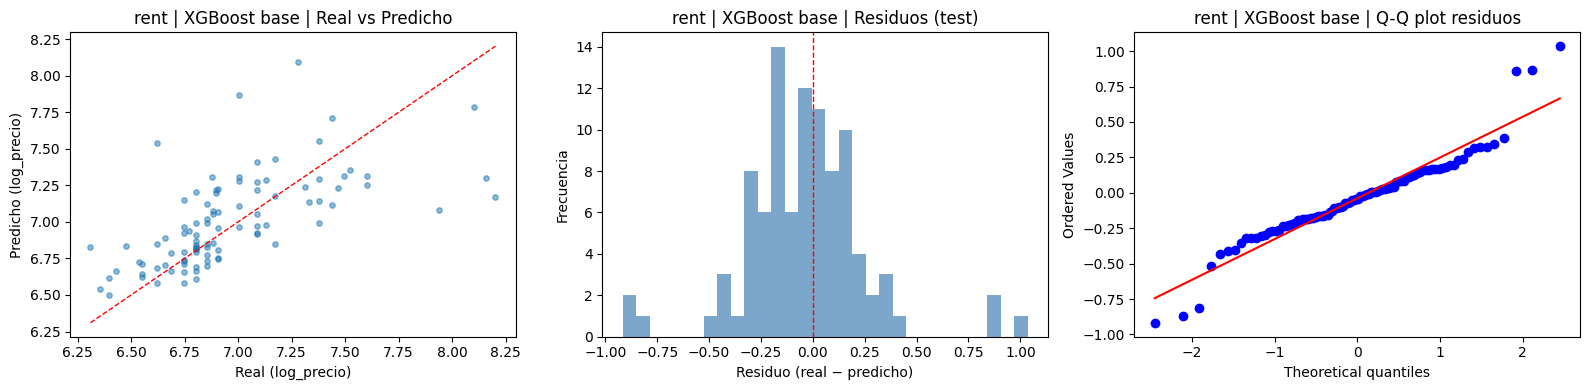

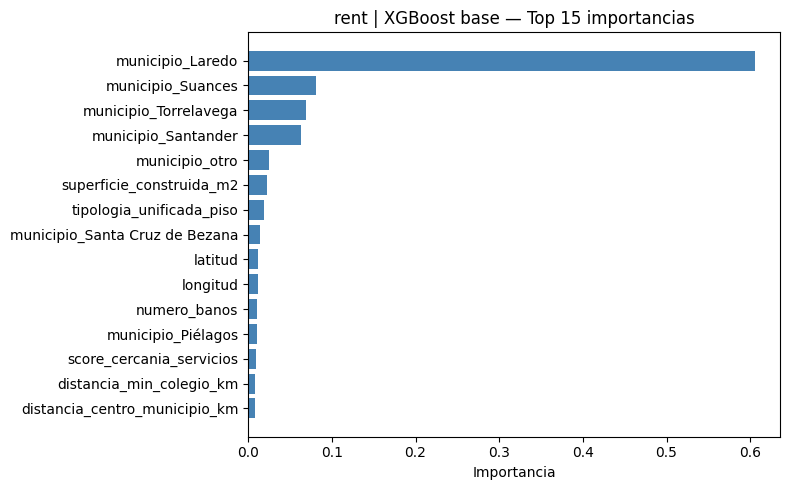


--- XGBoost | GridSearch (192 combinaciones, CV=5) ---
  Mejores params: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 200, 'reg_lambda': 5, 'subsample': 0.7}
  CV RMSE (mejor): 0.29845
split     MSE    RMSE     MAE      R2    MAPE
train 0.03580 0.18921 0.13209 0.77428 0.01862
   CV     NaN 0.29845     NaN     NaN     NaN
 test 0.07757 0.27852 0.19545 0.43098 0.02754
  Sobreajuste → ratio RMSE test/train: 1.4720 | delta R2: 0.3433


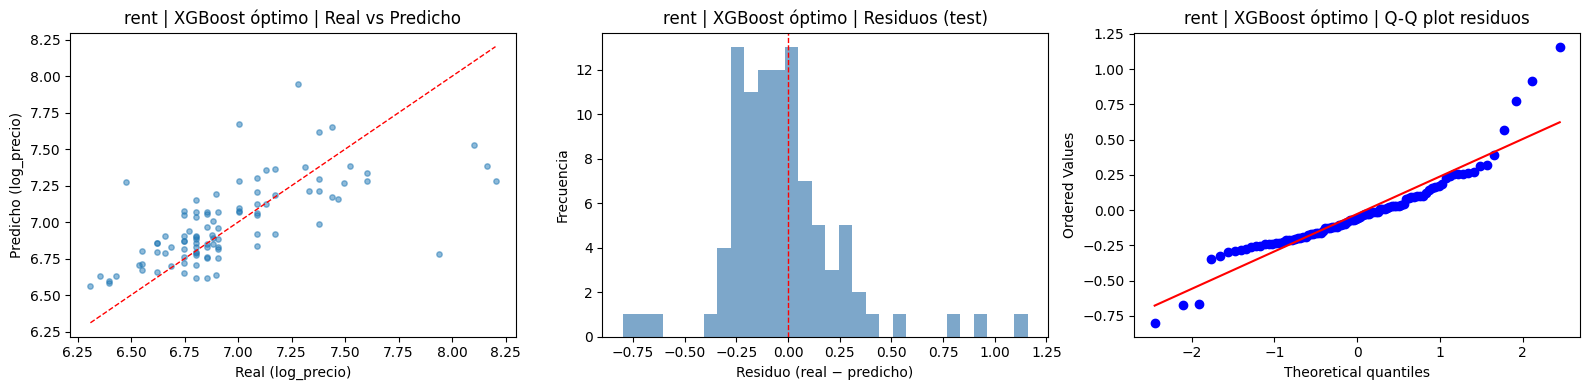

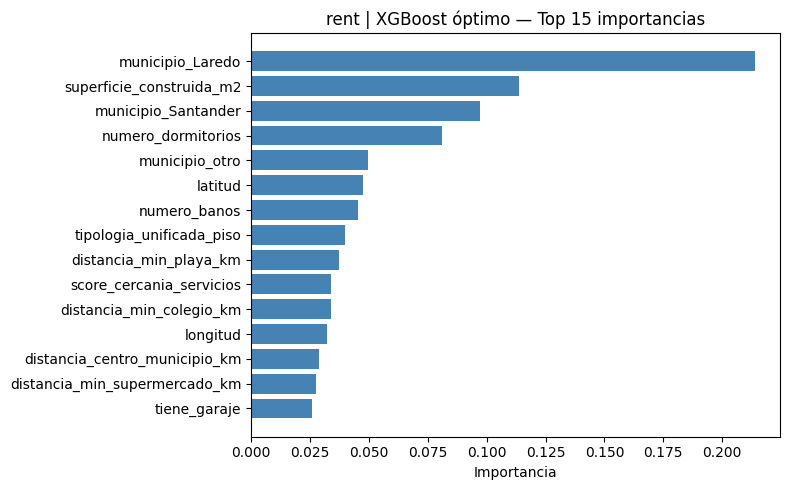


────────────────────────────────────────────────────────────
GRADIENT BOOSTING (sklearn)
────────────────────────────────────────────────────────────

--- GBR | Modelo base ---
split     MSE    RMSE     MAE      R2    MAPE
train 0.02337 0.15288 0.11216 0.85264 0.01588
 test 0.09518 0.30851 0.21852 0.30181 0.03104
  Sobreajuste → ratio RMSE test/train: 2.0180 | delta R2: 0.5508


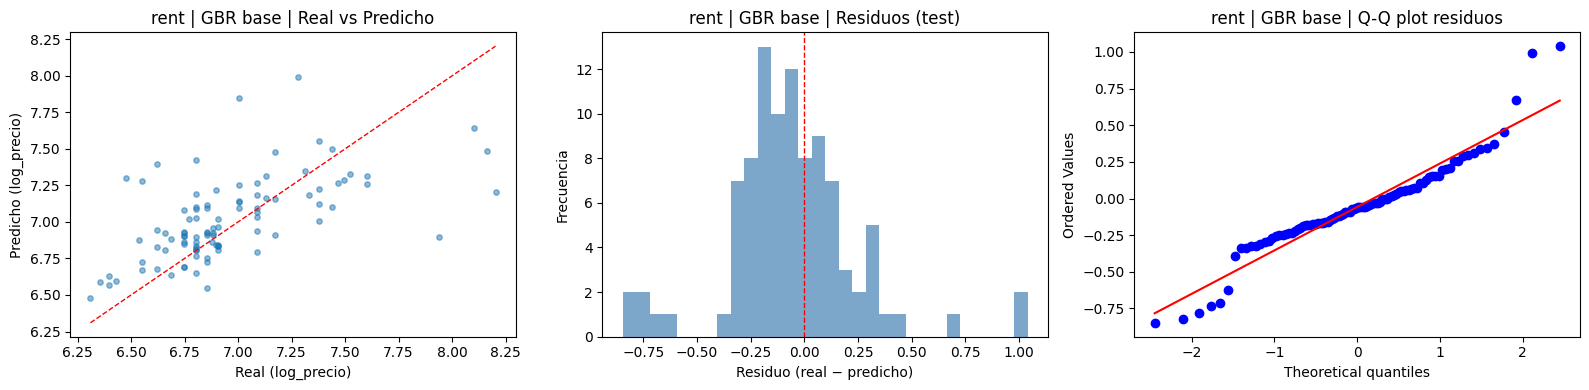

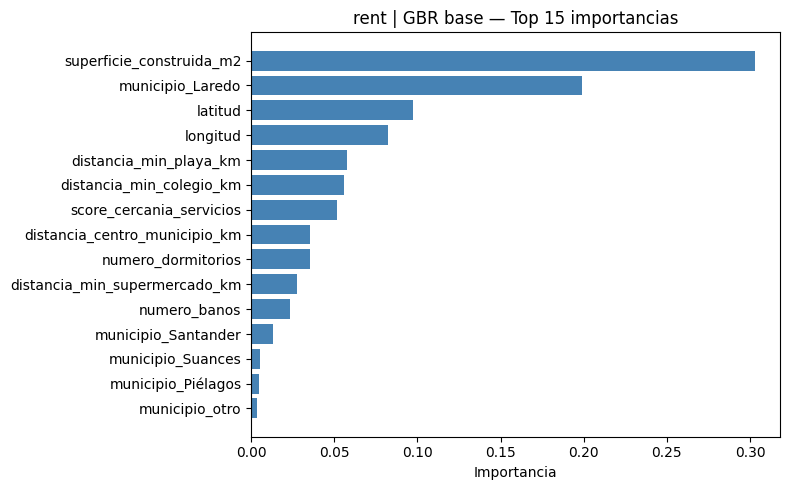


--- GBR | GridSearch (48 combinaciones, CV=5) ---
  Mejores params: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 10, 'n_estimators': 200, 'subsample': 0.9}
  CV RMSE (mejor): 0.30038
split     MSE    RMSE     MAE      R2    MAPE
train 0.03549 0.18840 0.13133 0.77621 0.01853
   CV     NaN 0.30038     NaN     NaN     NaN
 test 0.07941 0.28180 0.20109 0.41746 0.02839
  Sobreajuste → ratio RMSE test/train: 1.4958 | delta R2: 0.3587


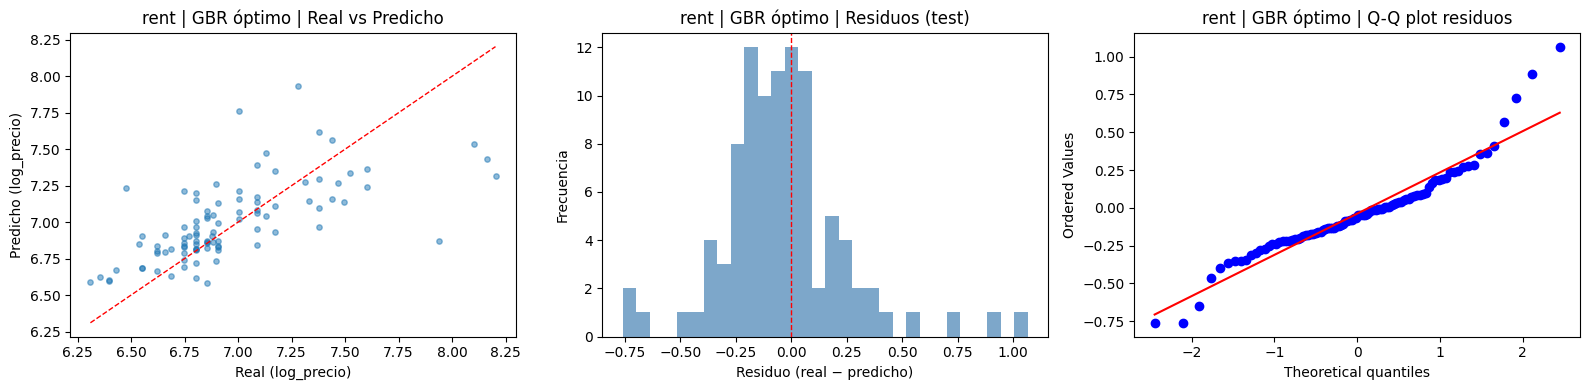

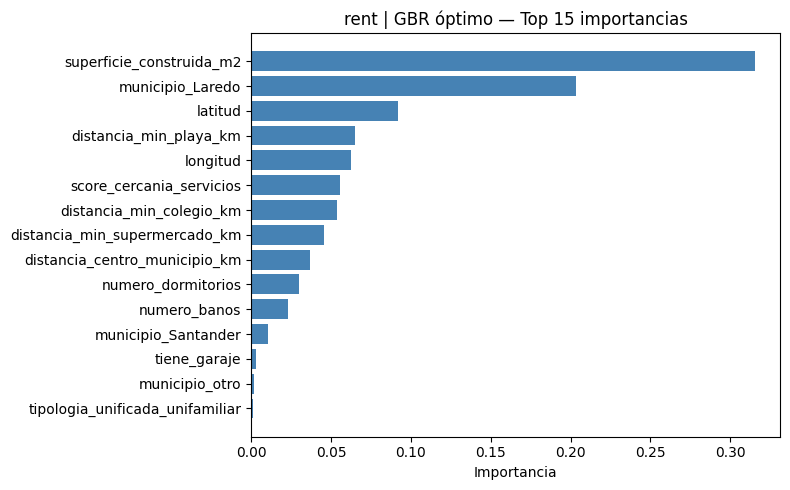


────────────────────────────────────────────────────────────
ADABOOST
────────────────────────────────────────────────────────────

--- AdaBoost | Modelo base ---
split     MSE    RMSE     MAE      R2    MAPE
train 0.08428 0.29031 0.24751 0.46859 0.03563
 test 0.11682 0.34180 0.28310 0.14304 0.04075
  Sobreajuste → ratio RMSE test/train: 1.1774 | delta R2: 0.3256


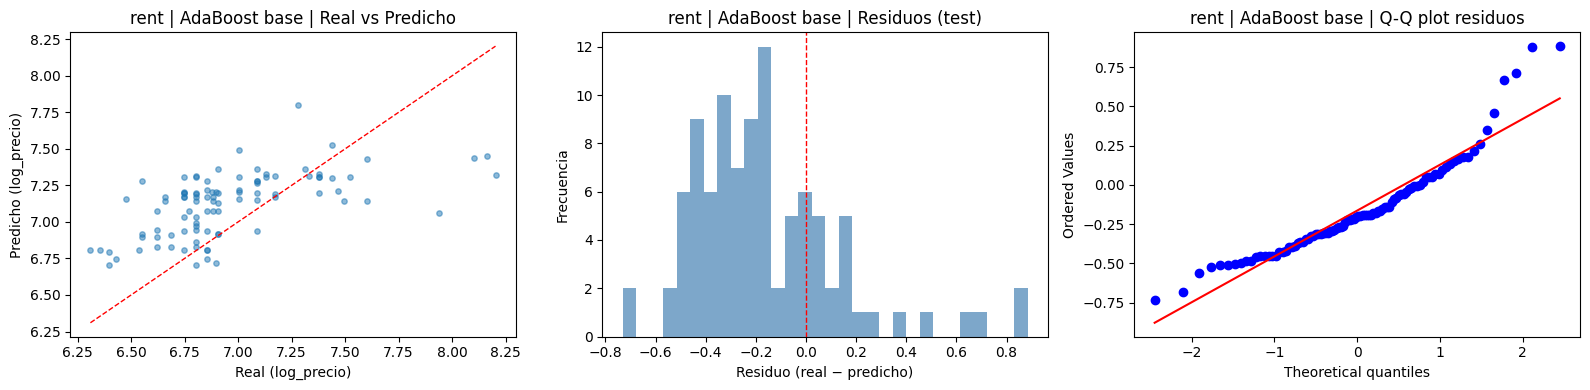

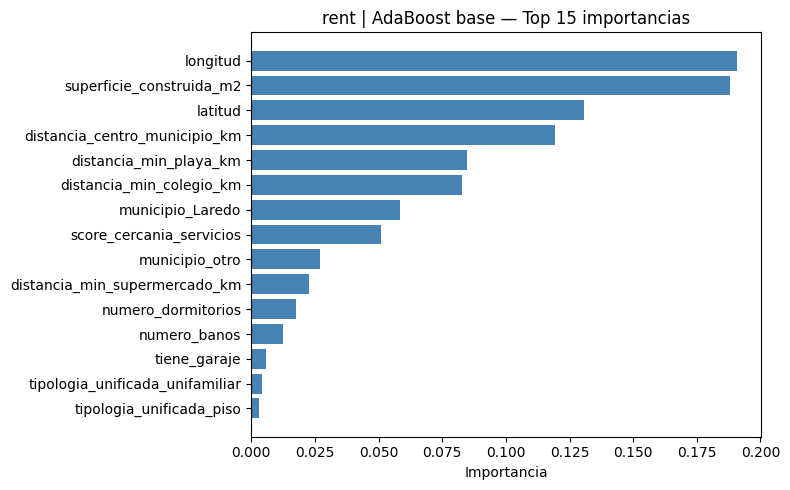


--- AdaBoost | GridSearch (27 combinaciones, CV=5) ---
  Mejores params: {'estimator__max_depth': 7, 'learning_rate': 0.5, 'n_estimators': 100}
  CV RMSE (mejor): 0.30950
split     MSE    RMSE     MAE      R2    MAPE
train 0.01241 0.11141 0.08783 0.92174 0.01272
   CV     NaN 0.30950     NaN     NaN     NaN
 test 0.08974 0.29957 0.20690 0.34169 0.02921
  Sobreajuste → ratio RMSE test/train: 2.6889 | delta R2: 0.5800


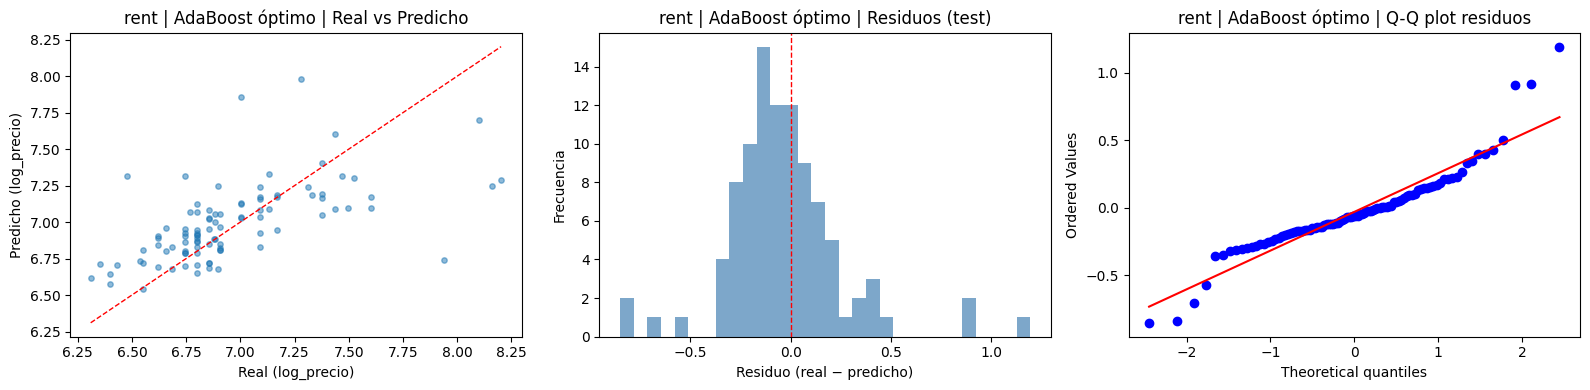

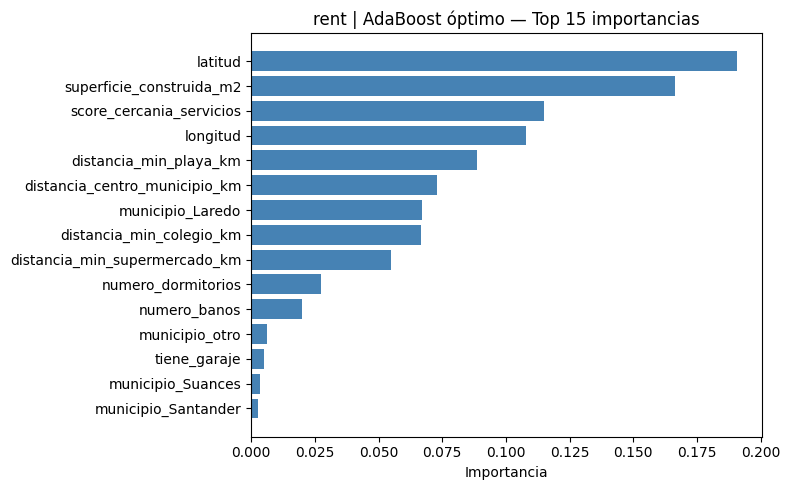


RESUMEN RENT — comparativa modelos
dataset   modelo   fase  train_RMSE  test_RMSE  train_R2  test_R2  cv_RMSE
   rent  XGBoost   base     0.02738    0.29694   0.99527  0.35319      NaN
   rent  XGBoost optimo     0.18921    0.27852   0.77428  0.43098  0.29845
   rent      GBR   base     0.15288    0.30851   0.85264  0.30181      NaN
   rent      GBR optimo     0.18840    0.28180   0.77621  0.41746  0.30038
   rent AdaBoost   base     0.29031    0.34180   0.46859  0.14304      NaN
   rent AdaBoost optimo     0.11141    0.29957   0.92174  0.34169  0.30950

RESUMEN GLOBAL
dataset   modelo   fase  train_RMSE  test_RMSE  train_R2  test_R2  cv_RMSE
   sale  XGBoost   base     0.00624    0.31869   0.99988  0.62697      NaN
   sale  XGBoost optimo     0.12483    0.31240   0.95230  0.64155  0.35709
   sale      GBR   base     0.19815    0.32739   0.87982  0.60633      NaN
   sale      GBR optimo     0.20309    0.30623   0.87375  0.65558  0.36481
   sale AdaBoost   base     0.30849    0.35500  

,dataset,modelo,fase,train_RMSE,test_RMSE,train_R2,test_R2,cv_RMSE
0,sale,XGBoost,base,0.00624,0.31869,0.99988,0.62697,NaN
1,sale,XGBoost,optimo,0.12483,0.31240,0.95230,0.64155,0.357094
2,sale,GBR,base,0.19815,0.32739,0.87982,0.60633,NaN
3,sale,GBR,optimo,0.20309,0.30623,0.87375,0.65558,0.364808
4,sale,AdaBoost,base,0.30849,0.35500,0.70870,0.53714,NaN
5,sale,AdaBoost,optimo,0.09897,0.29881,0.97001,0.67207,0.356010
6,rent,XGBoost,base,0.02738,0.29694,0.99527,0.35319,NaN
7,rent,XGBoost,optimo,0.18921,0.27852,0.77428,0.43098,0.298446
8,rent,GBR,base,0.15288,0.30851,0.85264,0.30181,NaN
9,rent,GBR,optimo,0.18840,0.28180,0.77621,0.41746,0.300381


In [4]:
# ── Bucle principal: un bloque por dataset ────────────────────────────────────

all_summary_rows = []

for dataset_name, dataset_path in DATASETS.items():
    print()
    print("=" * 100)
    print(f"DATASET: {dataset_name.upper()}")
    print("=" * 100)

    # ── Carga ─────────────────────────────────────────────────────────────────
    df = pd.read_csv(dataset_path)
    df = df[df[TARGET_COL].notna()].copy()
    print(f"Filas cargadas: {len(df)}")

    # ── Colapsar municipios raros ─────────────────────────────────────────────
    print(f"\nAgrupando municipios con < {MIN_OBS_MUNICIPIO} observaciones:")
    df, final_muni_cols = collapse_rare_municipios(df, MUNICIPIO_FEATURES, MIN_OBS_MUNICIPIO)

    # ── Preparar features ─────────────────────────────────────────────────────
    all_feature_cols = BASE_FEATURES + final_muni_cols
    X = prepare_X(df, all_feature_cols)
    y = df[TARGET_COL].reset_index(drop=True)

    # alinear índices tras reset del imputer
    y = df[TARGET_COL].values

    print(f"Features finales: {X.shape[1]} | Filas: {X.shape[0]}")

    # ── Split 80/20 ───────────────────────────────────────────────────────────
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    print(f"Train: {len(X_train)} | Test: {len(X_test)}")

    feature_names = X_train.columns.tolist()

    # ══════════════════════════════════════════════════════════════════════════
    # 1. XGBoost
    # ══════════════════════════════════════════════════════════════════════════
    print("\n" + "─" * 60)
    print("XGBOOST")
    print("─" * 60)

    # Base
    xgb_base = XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    xgb_base, xgb_base_train, xgb_base_test = run_base_model(
        xgb_base, X_train, X_test, y_train, y_test, "XGBoost", dataset_name
    )
    plot_diagnostics(y_test, xgb_base.predict(X_test), f"{dataset_name} | XGBoost base")
    fi_xgb_base = plot_feature_importance(
        xgb_base.feature_importances_, feature_names,
        f"{dataset_name} | XGBoost base — Top 15 importancias"
    )

    # Grid Search
    xgb_opt, xgb_gs, xgb_opt_train, xgb_opt_test, xgb_cv_rmse = run_grid_search(
        XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
        PARAM_GRID_XGB, X_train, X_test, y_train, y_test, "XGBoost", dataset_name
    )
    plot_diagnostics(y_test, xgb_opt.predict(X_test), f"{dataset_name} | XGBoost óptimo")
    fi_xgb_opt = plot_feature_importance(
        xgb_opt.feature_importances_, feature_names,
        f"{dataset_name} | XGBoost óptimo — Top 15 importancias"
    )

    # ══════════════════════════════════════════════════════════════════════════
    # 2. GradientBoosting
    # ══════════════════════════════════════════════════════════════════════════
    print("\n" + "─" * 60)
    print("GRADIENT BOOSTING (sklearn)")
    print("─" * 60)

    # Base
    gbr_base = GradientBoostingRegressor(random_state=RANDOM_STATE)
    gbr_base, gbr_base_train, gbr_base_test = run_base_model(
        gbr_base, X_train, X_test, y_train, y_test, "GBR", dataset_name
    )
    plot_diagnostics(y_test, gbr_base.predict(X_test), f"{dataset_name} | GBR base")
    fi_gbr_base = plot_feature_importance(
        gbr_base.feature_importances_, feature_names,
        f"{dataset_name} | GBR base — Top 15 importancias"
    )

    # Grid Search
    gbr_opt, gbr_gs, gbr_opt_train, gbr_opt_test, gbr_cv_rmse = run_grid_search(
        GradientBoostingRegressor(random_state=RANDOM_STATE),
        PARAM_GRID_GBR, X_train, X_test, y_train, y_test, "GBR", dataset_name
    )
    plot_diagnostics(y_test, gbr_opt.predict(X_test), f"{dataset_name} | GBR óptimo")
    fi_gbr_opt = plot_feature_importance(
        gbr_opt.feature_importances_, feature_names,
        f"{dataset_name} | GBR óptimo — Top 15 importancias"
    )

    # ══════════════════════════════════════════════════════════════════════════
    # 3. AdaBoost
    # ══════════════════════════════════════════════════════════════════════════
    print("\n" + "─" * 60)
    print("ADABOOST")
    print("─" * 60)

    # Base
    ada_base = AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=3),
        random_state=RANDOM_STATE,
    )
    ada_base, ada_base_train, ada_base_test = run_base_model(
        ada_base, X_train, X_test, y_train, y_test, "AdaBoost", dataset_name
    )
    plot_diagnostics(y_test, ada_base.predict(X_test), f"{dataset_name} | AdaBoost base")
    fi_ada_base = plot_feature_importance(
        ada_base.feature_importances_, feature_names,
        f"{dataset_name} | AdaBoost base — Top 15 importancias"
    )

    # Grid Search
    ada_opt, ada_gs, ada_opt_train, ada_opt_test, ada_cv_rmse = run_grid_search(
        AdaBoostRegressor(estimator=DecisionTreeRegressor(), random_state=RANDOM_STATE),
        PARAM_GRID_ADA, X_train, X_test, y_train, y_test, "AdaBoost", dataset_name
    )
    plot_diagnostics(y_test, ada_opt.predict(X_test), f"{dataset_name} | AdaBoost óptimo")
    fi_ada_opt = plot_feature_importance(
        ada_opt.feature_importances_, feature_names,
        f"{dataset_name} | AdaBoost óptimo — Top 15 importancias"
    )

    # ══════════════════════════════════════════════════════════════════════════
    # Resumen del dataset
    # ══════════════════════════════════════════════════════════════════════════
    print("\n" + "=" * 60)
    print(f"RESUMEN {dataset_name.upper()} — comparativa modelos")
    print("=" * 60)

    rows = [
        {"dataset": dataset_name, "modelo": "XGBoost",  "fase": "base",
         "train_RMSE": float(xgb_base_train["RMSE"].iloc[0]), "test_RMSE": float(xgb_base_test["RMSE"].iloc[0]),
         "train_R2":   float(xgb_base_train["R2"].iloc[0]),   "test_R2":   float(xgb_base_test["R2"].iloc[0]),   "cv_RMSE": None},
        {"dataset": dataset_name, "modelo": "XGBoost",  "fase": "optimo",
         "train_RMSE": float(xgb_opt_train["RMSE"].iloc[0]),  "test_RMSE": float(xgb_opt_test["RMSE"].iloc[0]),
         "train_R2":   float(xgb_opt_train["R2"].iloc[0]),    "test_R2":   float(xgb_opt_test["R2"].iloc[0]),    "cv_RMSE": xgb_cv_rmse},
        {"dataset": dataset_name, "modelo": "GBR",      "fase": "base",
         "train_RMSE": float(gbr_base_train["RMSE"].iloc[0]), "test_RMSE": float(gbr_base_test["RMSE"].iloc[0]),
         "train_R2":   float(gbr_base_train["R2"].iloc[0]),   "test_R2":   float(gbr_base_test["R2"].iloc[0]),   "cv_RMSE": None},
        {"dataset": dataset_name, "modelo": "GBR",      "fase": "optimo",
         "train_RMSE": float(gbr_opt_train["RMSE"].iloc[0]),  "test_RMSE": float(gbr_opt_test["RMSE"].iloc[0]),
         "train_R2":   float(gbr_opt_train["R2"].iloc[0]),    "test_R2":   float(gbr_opt_test["R2"].iloc[0]),    "cv_RMSE": gbr_cv_rmse},
        {"dataset": dataset_name, "modelo": "AdaBoost", "fase": "base",
         "train_RMSE": float(ada_base_train["RMSE"].iloc[0]), "test_RMSE": float(ada_base_test["RMSE"].iloc[0]),
         "train_R2":   float(ada_base_train["R2"].iloc[0]),   "test_R2":   float(ada_base_test["R2"].iloc[0]),   "cv_RMSE": None},
        {"dataset": dataset_name, "modelo": "AdaBoost", "fase": "optimo",
         "train_RMSE": float(ada_opt_train["RMSE"].iloc[0]),  "test_RMSE": float(ada_opt_test["RMSE"].iloc[0]),
         "train_R2":   float(ada_opt_train["R2"].iloc[0]),    "test_R2":   float(ada_opt_test["R2"].iloc[0]),    "cv_RMSE": ada_cv_rmse},
    ]
    all_summary_rows.extend(rows)

    ds_summary = pd.DataFrame(rows)
    print(ds_summary.round(5).to_string(index=False))

print()
print("=" * 100)
print("RESUMEN GLOBAL")
print("=" * 100)
global_summary = pd.DataFrame(all_summary_rows)
print(global_summary.round(5).to_string(index=False))
global_summary